# SUPPORT VECTOR MACHINE
## Mushroom Dataset Classification. 

In [1]:
## ● Dataset Selection: For this assignment, we'll utilize the widely recognized Mushroom Dataset.

In [2]:
## ● Task 1: Exploratory Data Analysis (EDA)
## ● 1.	Load the Mushroom dataset and perform fundamental data exploration.
## ● 2.	Utilize histograms, box plots, or density plots to understand feature distributions.
## ● 3.	Investigate feature correlations to discern relationships within the data.

In [3]:
## Lets import required libraries in this assignmet..

## Data manipulation..
import pandas as pd
import numpy as np

## Data visualization..
import matplotlib.pyplot as plt
import seaborn as sns

## Ignore warnings.. 
import warnings
warnings.filterwarnings("ignore")

## Display settings..
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
## Load and display the dataset..
df = pd.read_csv("mushroom.csv")
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,stalk_root,stalk_surface_above_ring,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,cup,smooth,silky,gray,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,rooted,silky,silky,cinnamon,brown,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,cup,scaly,silky,yellow,gray,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,club,smooth,scaly,yellow,pink,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,missing,fibrous,scaly,gray,white,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [5]:
## Basic informations..

## Shape of the dataset..
print("Shape of the Dataset:", df.shape)

## Information..
print("\nDataset Information")
df.info()

## Statistical summary..
print("\nStatistical Summary")
display(df.describe(include = "all").T)

Shape of the Dataset: (2000, 26)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_sur

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,2000.0,NaN,NaN,NaN,624.974,375.091938,0.0,290.0,607.0,957.25,1279.0
cap_shape,2000,5,sunken,439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_surface,2000,4,scaly,568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_color,2000,9,brown,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bruises,2000,2,yes,1023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odor,2000,9,foul,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill_attachment,2000,4,free,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill_spacing,2000,3,distant,677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill_size,2000,2,narrow,1007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill_color,2000,12,orange,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
## Cross checking missing values..
df.isnull().sum().sum()

np.int64(0)

In [7]:
## Check number of Duplicate records..
print("Number of Duplicate Records:", df.duplicated().sum())

Number of Duplicate Records: 1024


In [8]:
df["Unnamed: 0"].nunique()

976

In [9]:
## The dataset contain 2000 records and 26 features..
## It is sufficiently large and feature rich dataset for EDA and SVM classification model..
## The dataset contain 23 categorical features and 2 float features and 1 integer feature..
## The missing values analysis shows no missing values, therefore no missing value treatment or imputation required..
## The dataset contain 1024 duplicate records out of 2000 records..means more than half of the records are duplicates..
## These duplicates should be carefully considred and may be removed during preprocessing to avoid introducing bias and redundancy into SVM model.. 
## Also I noticed that the column "Unnamed: 0" has random numbers, with no meaningful predictive feature.. we will deal with it later..

In [10]:
## Lets explore target variable..
print("Value Counts")
print(df["class"].value_counts()) ## frequency of target variable.. 
print("*"*100)
## Percentage distribution..
print("Value Count Percentage per Categories")
print(round(df["class"].value_counts(normalize = True)*100, 2))

Value Counts
class
poisonous    1400
edible        600
Name: count, dtype: int64
****************************************************************************************************
Value Count Percentage per Categories
class
poisonous    70.0
edible       30.0
Name: proportion, dtype: float64


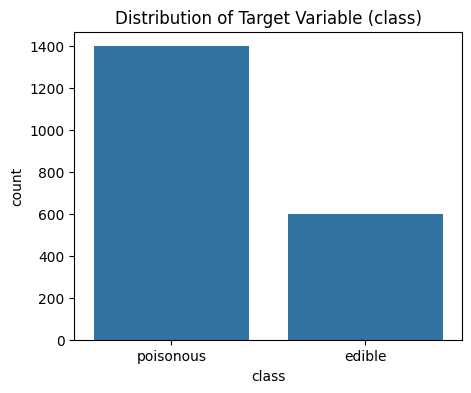

In [11]:
## Visualization..
plt.figure(figsize = (5,4))
sns.countplot(x = "class", data =df)
plt.title("Distribution of Target Variable (class)")
plt.show()

In [12]:
## The target variable distribution shows that 70% of the mushrooms are poisonous while 30% are edible..
## This indicates the presence of moderate imbalance in dataset with poisonous mushrooms being dominant class..

In [13]:
## Lets explore numerical features.. 
df[["stalk_height", "cap_diameter"]].describe()

,stalk_height,cap_diameter
count,2000.000000,2000.000000
mean,8.449118,12.314345
std,3.697217,7.048845
min,2.000000,1.000000
25%,5.291009,5.723521
50%,8.318596,12.124902
75%,11.781272,18.698605
max,15.095066,25.000054


In [14]:
## The numerical fetaures "stalk_height" and "cap_diameter" exibits broad range of values withs means of approximately 8.44 and and 12.31, respectively..
## The mean and 50% percentile (median) values being similar suggest no skewness in the columns, although its not abosolute conclusion.. 

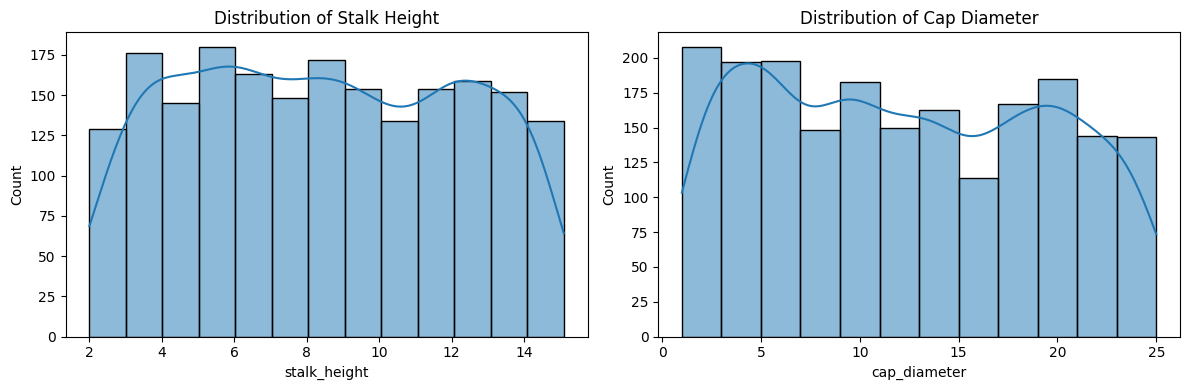

In [15]:
## Histogram..
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
sns.histplot(df["stalk_height"], kde = True, ax = axes[0])
axes[0].set_title("Distribution of Stalk Height")
sns.histplot(df["cap_diameter"], kde = True, ax = axes[1])
axes[1].set_title("Distribution of Cap Diameter")
plt.tight_layout()
plt.show()

In [16]:
## The histogram for both "stalk_height" and "cap_diameter" suggests that the observations are fairly spread across their ranges rather than being heavly concentrated at a single value..

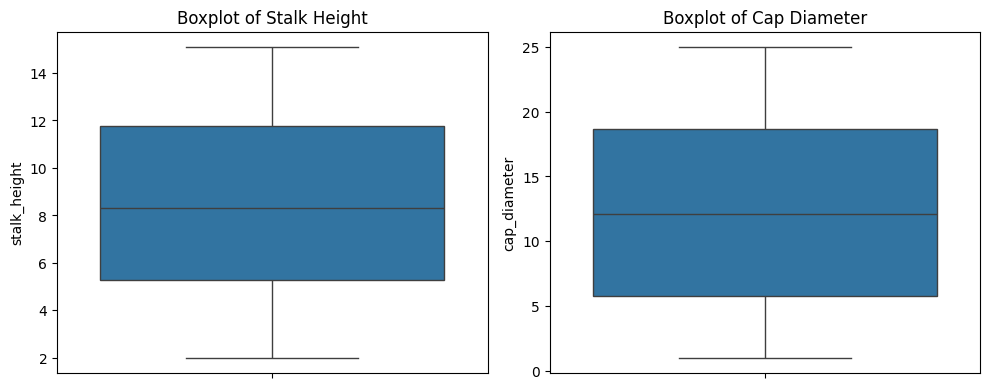

In [17]:
## Boxplot.. 
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
sns.boxplot(y = df["stalk_height"], ax = axes[0])
axes[0].set_title("Boxplot of Stalk Height")
sns.boxplot(y = df["cap_diameter"], ax = axes[1])
axes[1].set_title("Boxplot of Cap Diameter")
plt.tight_layout()
plt.show()

In [18]:
## The boxplot do not indicate any prominant outliers..
## This suggests that numerical features are relatively well behaved and unlikely to require outlier treatment..

In [19]:
num_cols = ["stalk_height", "cap_diameter"]

In [20]:
## IQR calculation for numerical columns.. 
for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
    print("*"*100)
##    if len(outliers) > 0:
##        print("Potential Outliers:")
##        print(outliers.values)
    
##    plt.figure(figsize = (7, 2))
##    plt.boxplot(df[i].dropna(), vert = False)
##    plt.title(f"Boxplot of {i}")
##    plt.show()


Column: stalk_height
Q1 : 5.2910089106810005
Q3 : 11.781272039772865
IQR : 6.490263129091865
Lower Bound : -4.444385782956797
Upper Bound : 21.516666733410663
Minimum Value : 2.0
Maximum Value : 15.095065892005046
Potential Outiers : 0
****************************************************************************************************

Column: cap_diameter
Q1 : 5.7235209505112845
Q3 : 18.69860549814206
IQR : 12.975084547630777
Lower Bound : -13.73910587093488
Upper Bound : 38.16123231958822
Minimum Value : 1.0
Maximum Value : 25.000053842997023
Potential Outiers : 0
****************************************************************************************************


In [21]:
## From IQR calculation we double checked that there are no potential outliers present in the numerical columns.. 
## We calculated potential outliers using lower bound, upper bound, lower quartile and upper quartiles.. 

In [22]:
## Lets explore few categorical fetaures..
categorical_cols = ['cap_shape', 'cap_surface', 'cap_color', 'odor', 'habitat']
for i in categorical_cols:
    print(f"\nValue Counts for {i}")
    print(df[i].value_counts())


Value Counts for cap_shape
cap_shape
sunken     439
flat       402
bell       397
convex     381
conical    381
Name: count, dtype: int64

Value Counts for cap_surface
cap_surface
scaly      568
smooth     513
fibrous    482
grooves    437
Name: count, dtype: int64

Value Counts for cap_color
cap_color
brown     263
green     241
yellow    228
gray      226
pink      221
buff      220
red       216
white     200
purple    185
Name: count, dtype: int64

Value Counts for odor
odor
foul        274
anise       242
musty       239
fishy       228
spicy       226
pungent     212
almond      203
creosote    197
none        179
Name: count, dtype: int64

Value Counts for habitat
habitat
urban      316
woods      295
meadows    294
leaves     293
waste      280
paths      275
grasses    247
Name: count, dtype: int64


In [23]:
## The selected categorical variables show that observations are distributed across multiple categories..
## For example, sunken is the most common cap shape, scaly is the most frequent cap surface, brown is the most common cap color, 
## foul odor has the highest frequency and urban is the most common habitat in the dataset..
## The frequency seems to be aprroximtely balanced among all the categories in all the respective variable..
## No categories seems to be in absolute minority..
## The reason behind the selection of certain categorical variables only for value counts checks because they seems to be representative and commonly analyzed in mushroom datasets..
## Other tham that there is no other reason, the are not special in any way..
## Showing all 23 would make the notebook unnecessarily long and repetitive.. 

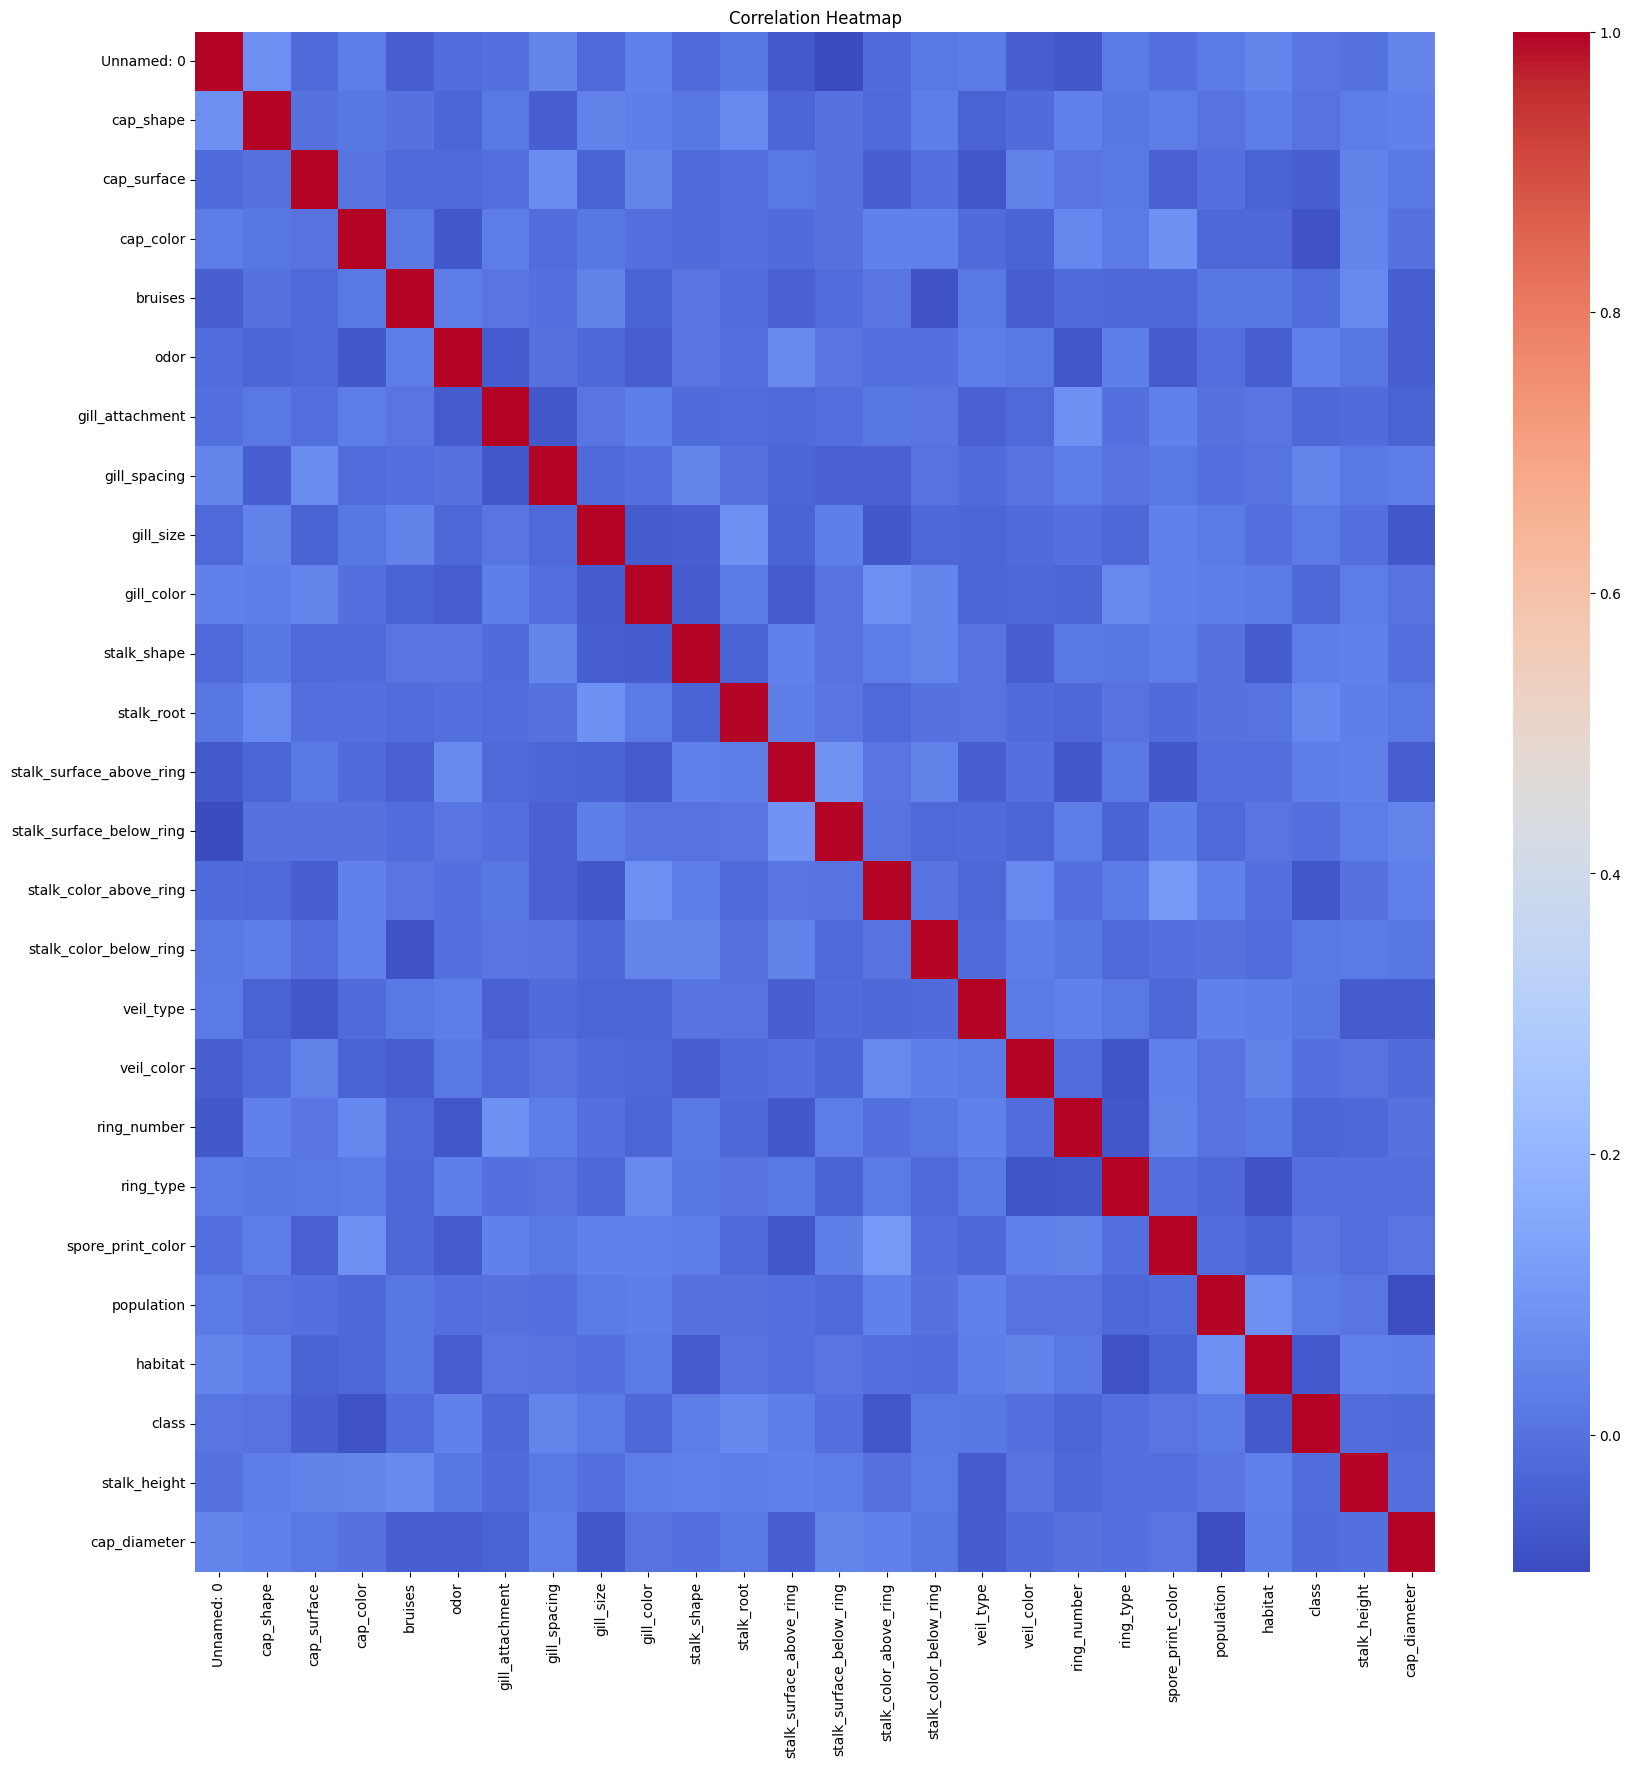

In [24]:
## Temporary (encoding) correlation analysis..
from sklearn.preprocessing import LabelEncoder

## lets create a copy for temporary correlation analysis
corr_df = df.copy()

le = LabelEncoder()
for i in corr_df.columns:
    if corr_df[i].dtype == "object":
        corr_df[i] = le.fit_transform(corr_df[i])
corr = corr_df.corr()

plt.figure(figsize= (20,20))
sns.heatmap(corr, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
## The correlation heatmap indicates that most features exhibits weak linear correlations with one another..
## This suggests limited multicollinearity.. 
## This implies that the feature largely  provide distinct information, which is benificial for subsequent model development..

#### Task 2: Data Preprocessing

In [26]:
## ● 1.	Encode categorical variables if necessary.
## ● 2.	Split the dataset into training and testing sets.

In [27]:
## Before encoding and splitting the dataset into training and testing parts, we need to address two remaining issues..
## 1st: investigate column "Unnamed: 0" 
## 2nd: deal with duplicate records.. 

In [28]:
## Investigate columns "Unnamed: 0"
df["Unnamed: 0"].head(20)

0     1167
1     1037
2      309
3      282
4      820
5      389
6      330
7       98
8      597
9       16
10     243
11     621
12     875
13     221
14    1178
15     236
16    1279
17     539
18    1117
19     857
Name: Unnamed: 0, dtype: int64

In [29]:
print("Unique values:", df["Unnamed: 0"].nunique())
print("Duplicate values in Unnamed: 0", df["Unnamed: 0"].duplicated().sum())

Unique values: 976
Duplicate values in Unnamed: 0 1024


In [30]:
df["Unnamed: 0"].describe()

count    2000.000000
mean      624.974000
std       375.091938
min         0.000000
25%       290.000000
50%       607.000000
75%       957.250000
max      1279.000000
Name: Unnamed: 0, dtype: float64

In [31]:
## Number of duplicate rows in the dataset.. 
print("Duplicate rows in Dataset:", df.duplicated().sum())

Duplicate rows in Dataset: 1024


In [32]:
## Display duplicate rows..
df[df.duplicated()].head(10)

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,stalk_root,stalk_surface_above_ring,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
34,1279,bell,smooth,pink,no,foul,notched,distant,broad,pink,enlarging,rooted,smooth,fibrous,brown,pink,universal,brown,one,zone,black,scattered,leaves,poisonous,5.291009,5.436304
70,1275,sunken,scaly,yellow,no,pungent,descending,distant,narrow,orange,enlarging,rooted,fibrous,fibrous,red,red,partial,white,none,zone,white,numerous,leaves,poisonous,4.746453,10.769935
76,549,conical,grooves,brown,no,foul,free,distant,broad,white,tapering,rooted,smooth,fibrous,buff,gray,partial,yellow,two,large,chocolate,solitary,woods,poisonous,12.206952,5.061715
109,1198,sunken,smooth,white,no,anise,attached,crowded,broad,black,tapering,bulbous,scaly,scaly,orange,red,partial,brown,two,sheathing,black,solitary,woods,edible,13.214007,14.549171
127,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,cup,smooth,silky,gray,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
134,986,sunken,smooth,red,no,almond,notched,crowded,narrow,white,enlarging,cup,silky,silky,gray,pink,partial,orange,none,evanescent,chocolate,several,paths,poisonous,14.088450,18.496169
135,879,flat,grooves,green,no,foul,free,crowded,narrow,gray,tapering,rhizomorphs,fibrous,scaly,yellow,cinnamon,universal,orange,two,zone,black,abundant,urban,poisonous,11.938913,16.818947
144,884,conical,smooth,gray,no,fishy,notched,close,narrow,pink,enlarging,bulbous,silky,smooth,yellow,red,universal,yellow,one,flaring,chocolate,clustered,leaves,poisonous,13.088260,2.217697
157,275,sunken,grooves,yellow,yes,almond,notched,close,narrow,yellow,tapering,rhizomorphs,silky,silky,cinnamon,cinnamon,universal,orange,two,flaring,white,clustered,paths,poisonous,12.938930,13.380007
159,707,sunken,grooves,white,yes,musty,notched,crowded,broad,white,enlarging,cup,silky,fibrous,white,white,partial,brown,one,pendant,orange,numerous,meadows,poisonous,13.572091,9.949051


In [33]:
## Shape before modfying the dataset..
print("Original shape of the Dataset:", df.shape)

Original shape of the Dataset: (2000, 26)


In [34]:
## After analyzing, column "Unnamed: 0" does not look like a meaningful feature such as stalk height or odor..
## It apprears to be an identifiers/ index like column..
## It has no biological meaning for mushroom classification..
## Keeping it may introduce unnecessary noice into the SVM model..

## Lets drop this..
df.drop(columns = ["Unnamed: 0"], inplace = True)
print("Shape of Dataset after removal of Unnamed: 0", df.shape)

Shape of Dataset after removal of Unnamed: 0 (2000, 25)


In [35]:
## We found out that we have more than 50% of the dataset as duplicate records (1024 out of 2000)..
## We should remove them because Duplicate observation adds redundant information..
## They can bias the SVM decision boundary.. removing them improves the data quality.. 

## Lets remove duplicate records..
df.drop_duplicates(inplace = True)

## New shape of the dataset after removal of the duplicate records.. 
print("Shape of the Dataset after the removal of Duplicate records:", df.shape)

Shape of the Dataset after the removal of Duplicate records: (976, 25)


In [36]:
## The "Unnamed: 0", an identifiers like variable with no meaningful predictive information and all the duplicate records are removed successfully..
## The shape of the dataset after removal of unwanted column and records is (976, 25)..
## The cleaned dataset is better suited for preprocessing and SVM classification.. 

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cap_shape                 976 non-null    object 
 1   cap_surface               976 non-null    object 
 2   cap_color                 976 non-null    object 
 3   bruises                   976 non-null    object 
 4   odor                      976 non-null    object 
 5   gill_attachment           976 non-null    object 
 6   gill_spacing              976 non-null    object 
 7   gill_size                 976 non-null    object 
 8   gill_color                976 non-null    object 
 9   stalk_shape               976 non-null    object 
 10  stalk_root                976 non-null    object 
 11  stalk_surface_above_ring  976 non-null    object 
 12  stalk_surface_below_ring  976 non-null    object 
 13  stalk_color_above_ring    976 non-null    object 
 14  stalk_color_be

In [38]:
## Now lets encode the categorical columns.. I havr already impoted LabelEncoder during correlation test above..
## from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() ## LabelEncoder object

for i in df.select_dtypes(include = "object").columns:
    df[i] = le.fit_transform(df[i])

In [39]:
## Lets check if encoding was successfull or not
df.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,stalk_root,stalk_surface_above_ring,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,4,2,7,0,1,1,2,0,7,1,2,3,2,3,8,0,0,2,6,3,1,5,1,14.276173,5.054983
1,4,0,6,0,1,3,1,1,3,0,6,2,2,2,0,1,0,2,6,1,2,5,0,3.952715,19.068319
2,3,1,5,1,4,1,1,0,8,1,2,1,2,8,3,1,3,2,6,6,0,5,1,9.054265,7.205884
3,0,2,4,1,3,3,0,0,6,0,1,3,1,8,5,0,3,2,0,4,1,0,1,5.226499,20.932692
4,3,3,8,1,5,2,1,1,6,0,4,0,1,3,7,1,2,0,4,8,1,4,1,14.037532,12.545245


In [40]:
df.info() ## Lets verify the datatypes

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cap_shape                 976 non-null    int64  
 1   cap_surface               976 non-null    int64  
 2   cap_color                 976 non-null    int64  
 3   bruises                   976 non-null    int64  
 4   odor                      976 non-null    int64  
 5   gill_attachment           976 non-null    int64  
 6   gill_spacing              976 non-null    int64  
 7   gill_size                 976 non-null    int64  
 8   gill_color                976 non-null    int64  
 9   stalk_shape               976 non-null    int64  
 10  stalk_root                976 non-null    int64  
 11  stalk_surface_above_ring  976 non-null    int64  
 12  stalk_surface_below_ring  976 non-null    int64  
 13  stalk_color_above_ring    976 non-null    int64  
 14  stalk_color_be

In [41]:
## First seperate features and target..
X = df.drop("class", axis = 1)
Y = df["class"]

In [42]:
## Now lets split the data into training and test sets..
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

## stratify = Y used because the target has multiple classes and some classes have fewer sample..
## It will help maitain approximately the same class distribution in both training and testing sets.. 

In [43]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (780, 24)
Testing set shape: (196, 24)


In [44]:
## All the duplicate records were removed and "Unnamed: 0" column was also removed..
## Since SVM algorithm requires numerical inputs, all the categorical variables were successfully encoded into numerical values using LabelEncoder..
## The dataset is successfully divided into feature (X) and the target variable (Y)..
## An 80:20 train-test split was performed, resulting in 780 training samples and 196 testing samples..
## This will provide sufficient data for model training and unbiased performance evaluation..

#### Task 3: Data Visualization

In [45]:
## ● 1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
## ● 2.	Visualize class distributions to gauge dataset balance or imbalance.

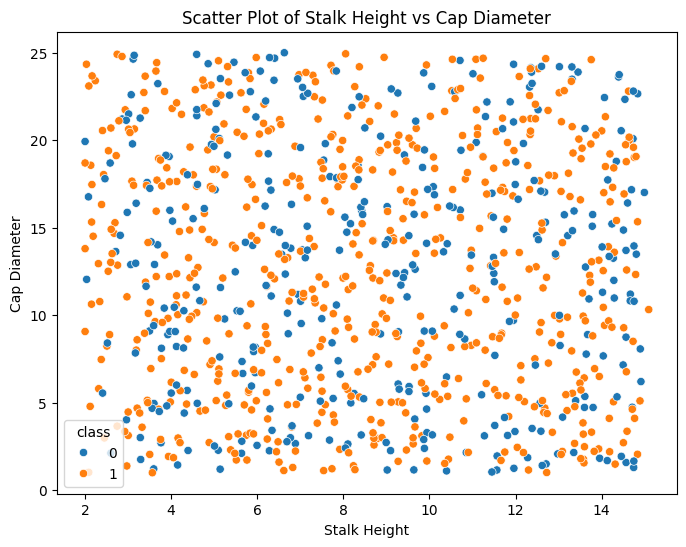

In [46]:
## Scatter plot..
plt.figure(figsize = (8, 6))
sns.scatterplot(data = df, x = "stalk_height", y = "cap_diameter", hue = "class")
plt.title("Scatter Plot of Stalk Height vs Cap Diameter")
plt.xlabel("Stalk Height")
plt.ylabel("Cap Diameter")
plt.show()

In [47]:
## The scatter plot of stalk height and cap diameter does not exibit any distinct pattern or clustering between the two musroom classes..
## Data points are widely and uniformly distributed across the plot with both classes overlapping throughtout the feature space..
## This indicates that these two numerical features alone are insufficient to clearly distinguish between edible and poisounous mushrooms..
## This suggets that the SVM model will need to leverage information from multiple  features for effective classification.. 

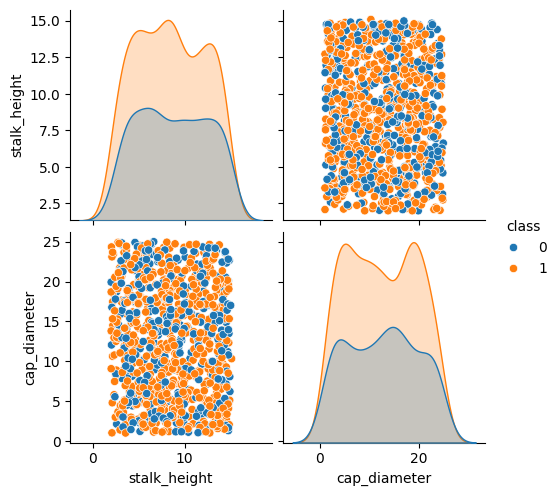

In [48]:
## Pair Plot..
sns.pairplot(df, vars = ["stalk_height", "cap_diameter"], hue = "class")
plt.show()

In [49]:
## The pair plot shows the relationship between stalk height and cap diameter for the two mushroom classes..
## The points of both classes are mixed together throughout the graph..
## There is no clear pattern showing that one class has larger or smaller values than the other..
## The distributions of stalk height and cap diameter also look very similar for both classes..
## No strong relationship can be seen between stalk height and cap diameter..
## The pair plot shows the relationship between stalk height and cap diameter for the two mushroom classes..
## Based on this plot, stalk height and cap diameter alone do not clearly separate the two mushroom classes..

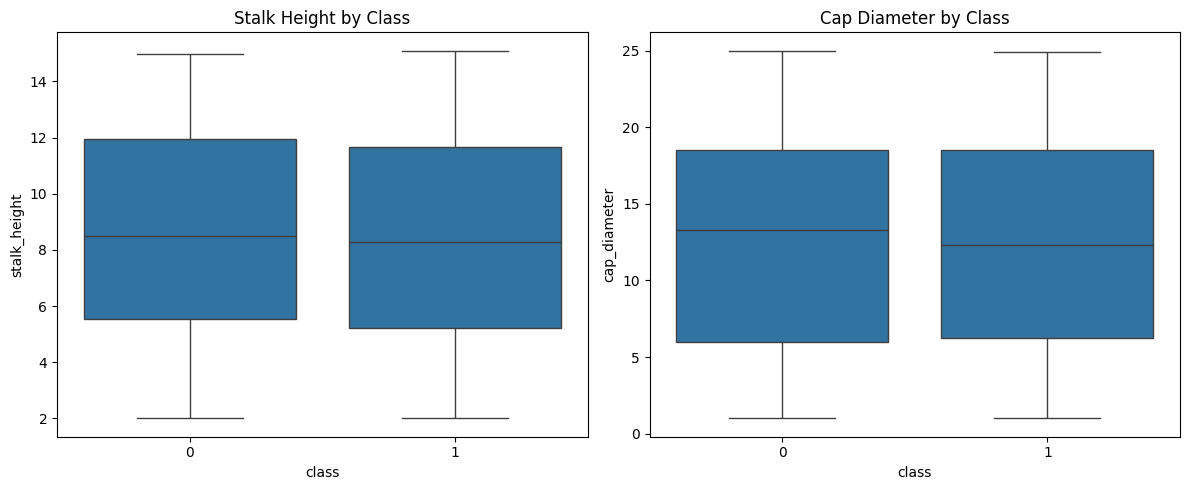

In [50]:
## Visualization of relationship using boxplots by class..
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

sns.boxplot(x = "class", y = "stalk_height", data = df, ax = axes[0])
axes[0].set_title("Stalk Height by Class")

sns.boxplot(x = "class", y = "cap_diameter", data = df, ax = axes[1])
axes[1].set_title("Cap Diameter by Class")

plt.tight_layout()
plt.show()

In [51]:
## The box plots compare stalk height and cap diameter across the two mushroom classes..

## Stalk Height: Both classes have almost the same median value..the spread of the data is very similar..
## There is a large overlap between the two classes.

## Cap Diameter: The median values are close for both classes.. the range and spread of values are also similar.
## The distributions overlap considerably

In [52]:
## The class distribution was alredy examined in Task 1 EDA, where dataset was found to contain appromaely 70% poisonous and 30% edible mushrooms..
## Therefore it is not repeated in this section to avoid redundancy and the focus placed on visualizing feature relationships through scatter plots and pair plots.. 

#### Task 4: SVM Implementation

In [53]:
## ● 1.	Implement a basic SVM classifier using Python libraries like scikit-learn..
## ● 2.	Train the SVM model on the training data..
## ● 3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score)..

In [54]:
## Import reqired required libraries.. 
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

In [55]:
## Lets build and train model..
svm_model = SVC(random_state = 42) ## create SVM classifier..
svm_model.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [56]:
## Prediction.. 
Y_pred = svm_model.predict(X_test)

In [57]:
## Evaluation.. 
print("Accuracy :", accuracy_score(Y_test, Y_pred))
print("Precision :", precision_score(Y_test, Y_pred))
print("Recall Score :", recall_score(Y_test, Y_pred))
print("F1 Score :", f1_score(Y_test, Y_pred))

Accuracy : 0.6326530612244898
Precision : 0.6326530612244898
Recall Score : 1.0
F1 Score : 0.775


In [58]:
## Classification report..
print("Classification Report :") 
print(classification_report(Y_test, Y_pred))

Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.63      1.00      0.78       124

    accuracy                           0.63       196
   macro avg       0.32      0.50      0.39       196
weighted avg       0.40      0.63      0.49       196



In [59]:
## Confusion matrix..
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[  0  72]
 [  0 124]]


In [60]:
## The basic SVM classifier achieved an accuracy of approximately 63.27%, with precision of 63.27%..
## Recall of 100% and an F1-score of 77.5%..
## The high recall indicates that the model successfully identified that the model successfully identified all instances of class 1 in the test set..

## However the classification report and confusuion matrix reveal that the model failed to correctly classify any instances of class 0..
## As all 72 samples belonging to this class were predicted as class 1.. 
## Also the precision, recall and F1 score for class 0 are 0.00 ..

## The results suggests that the default SVM model is biased toward the majority class and does not provide balanced performance across both classes..
## Therefore hyperparameter tuning and experimentation with different kernel functions are necessary to improve the classifier's overall performance and class discrimination..

#### Task 5: Visualization of SVM Results

In [61]:
## ● 1.	Visualize classification results on the testing data. 

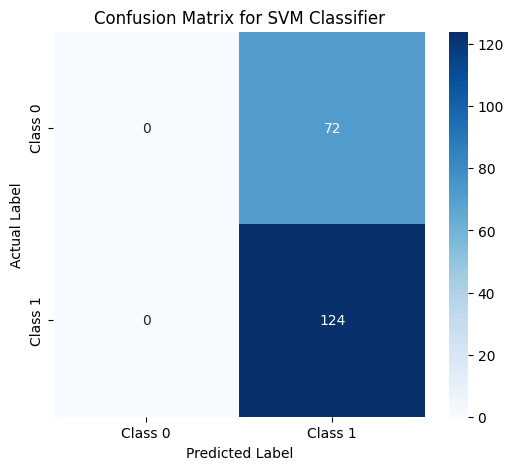

In [62]:
## Best way to visulalize the confusion matrix is through heatmap..
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = ["Class 0", "Class 1"], 
           yticklabels = ["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for SVM Classifier")
plt.show()

In [63]:
## As I said above as well, same results have been depicted in this plot as well..
## SVM classifier correctly classified 124 instances of class 1 but failed  to correctly identify any instances of class 0..
## All 72 class 0 instances were misclassified as class 1.. 

## This shows that the default SVM model is heavily baised toward predicting Class 1 and is unable to effectively distinguish between the two classes..
## Therefore further parameter tuning and experimentation with different kernel functions are required to improve classification performance..

In [64]:
## A confusuion matrix was used to visualize the SVM classification results because it clearly displays the number of correctlly and incorrectly classified instances for each calss..
## It provides a simple and effective way to evaluate the model's prediction performance on the testing data.. 

#### Task 6: Parameter Tuning and Optimization

In [65]:
## ● 1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [66]:
## We will compare Linear, Polynomial and RBF kernels as these are explicity required in next task as well..

## Linear Kernel
svm_linear = SVC(kernel = "linear", random_state = 42) ## Classifier creation..
svm_linear.fit(X_train, Y_train) ## Model trining..
Y_pred_linear = svm_linear.predict(X_test) ## Prediction.. 

## Polynomial Kernel
svm_poly = SVC(kernel = "poly", random_state = 42) ## Classifier creation..
svm_poly.fit(X_train, Y_train) ## Model trining..
Y_pred_poly = svm_poly.predict(X_test) ## Prediction..

## RBF Kernel
svm_rbf = SVC(kernel = "rbf", random_state = 42) ## Classifier creation..
svm_rbf.fit(X_train, Y_train) ## Model trining..
Y_pred_rbf = svm_rbf.predict(X_test) ## Prediction..

In [67]:
## Lets compare accuracies.. 
linear_acc = accuracy_score(Y_test, Y_pred_linear)
poly_acc = accuracy_score(Y_test, Y_pred_poly)
rbf_acc = accuracy_score(Y_test, Y_pred_rbf)

print("Linear Kernal Accuracy :", linear_acc)
print("Polynomial Kernel Accuracy :", poly_acc)
print("RBF Kernel Accuracy :", rbf_acc)

Linear Kernal Accuracy : 0.6326530612244898
Polynomial Kernel Accuracy : 0.6224489795918368
RBF Kernel Accuracy : 0.6326530612244898


In [68]:
## Different SVM kernel functions were evaluated to optimize the model's performance.. 
## The Linear and RBF kernels achieved the highest accuracy of approximately 63.27% ..
## The polynomial kernel achieved slightly lower accuracy of aprroximately 62.24%..
## Since the performance difference is minimal, changing the kernel along did not significamtly improved the model..
## This indicates that additional hyperparameter tuning such as varying C and gamma or further feature engineering may be required for better classification.. 

In [69]:
## Lets experiment with different values of C..
C_value = [0.1,1,5,10]
for i in C_value:
    model = SVC(kernel = "rbf", C = i, random_state = 42)
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    print(f"C = {i} --> Accuracy: {accuracy_score(Y_test, pred): .4f}")

C = 0.1 --> Accuracy:  0.6327
C = 1 --> Accuracy:  0.6327
C = 5 --> Accuracy:  0.6378
C = 10 --> Accuracy:  0.6020


In [70]:
## Here I saw that adjusting the regularization parameter can improve the model performance..
## Although the overall improvement over the baseline model was modest.. 

#### Task 7: Comparison and Analysis

In [71]:
## ● 1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
## ● 2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
## ● 3.	Discuss practical implications of SVM in real-world classification tasks.

In [72]:
## Lets create comparision table..
comparison = pd.DataFrame({"Kernel": ["Linear", "Polynomial", "RBF"], 
                           "Accuracy": [linear_acc, poly_acc, rbf_acc]})
comparison

,Kernel,Accuracy
0,Linear,0.632653
1,Polynomial,0.622449
2,RBF,0.632653


In [73]:
## Identify best kernel..
best_kernel = comparison.loc[comparison["Accuracy"].idxmax()]
print("Best Kernel:")
print(best_kernel)

Best Kernel:
Kernel        Linear
Accuracy    0.632653
Name: 0, dtype: object


In [74]:
##  Comparison of Kernels.. 
## The performance of three different SVM kernels was compared..
## The Linear and RBF kernels achieved an accuracy of approximately 63.27%, while the Polynomial kernel achieved a slightly lower accuracy of approximately 62.24%..
## Based on these results, the Linear kernel was selected as the best-performing kernel for this dataset, although the difference in performance among the kernels was relatively small..

In [75]:
## Strengths of SVM..
## SVM is an effective supervised learning algorithm for classification problems and performs well in high-dimensional feature spaces..
## It can model both linear and non-linear relationships through different kernel functions and is generally robust against overfitting when appropriate hyperparameters are selected..

## Weaknesses of SVM..
## SVM can be sensitive to the choice of kernel and hyperparameters, requiring careful tuning for optimal performance..
## It also typically requires proper feature scaling and may not perform well when the classes are highly overlapping or when the dataset characteristics are not well suited to SVM decision boundaries.

In [76]:
## Practical Implications in Real-World Classification Tasks..
## SVM is widely used in applications such as medical diagnosis, text classification, image recognition, and spam detection due to its strong classification capabilities..
## However, selecting the appropriate kernel, preprocessing the data correctly, and tuning hyperparameters are essential for achieving reliable performance in real-world problems.

In [77]:
## Final Conclusion:
## In this assignment, an SVM classifier was implemented and evaluated using the Mushroom dataset..
## Exploratory data analysis, preprocessing, visualization, model training, and hyperparameter tuning were successfully performed..
## The Linear kernel produced the best performance among the tested kernels with an accuracy of approximately 63.27%..
## While tuning the regularization parameter (C) further improved the accuracy to approximately 63.78%..
## The results demonstrate that SVM is a powerful classification technique, but its effectiveness depends on the dataset characteristics, preprocessing steps, and appropriate parameter selection.

In [78]:
## The moderate accuracy obtained in this assignment does not necessarily indicate that the SVM algorithm is ineffective..
## Different machine learning algorithms perform differently depending on the characteristics of the dataset..
## In some datasets, models such as Decision Trees may achieve significantly higher accuracy by capturing complex, non-linear relationships..
## Whereas SVM may not perform as well with its default settings..
## Furthermore, SVM is sensitive to feature scaling, and applying techniques such as StandardScaler, along with appropriate kernel and hyperparameter tuning, can often improve its performance..
## Therefore, model selection and preprocessing should always be guided by the nature of the dataset rather than assuming that one algorithm is universally superior.

In [79]:
## If this were a real industry project, I would almost certainly try StandardScaler + SVM and compare the results with your current model.. 
## It’s entirely possible that the accuracy would improve, but it’s also possible that another algorithm (like a Decision Tree or Random Forest) would still outperform SVM on this particular dataset..
## That’s why in practice we compare multiple models rather than assuming one is the best..